# LoraE Results and Visualization
This notebook provides a comprehensive view of the LoraE model performance across various scenarios and adaptive behaviors.

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

# Paths
model_dir = 'trained_models/LoraE_invi_visi_alpha_128/test/'
video_dir = 'visualizations/LoraE_invi_visi_alpha_128/'
master_csv = 'result/master_summary.csv'

scenarios = [
    'all_ignorant',
    'all_aware',
    'ignorant_to_aware_step25',
    'mixed_5050'
]

def load_results(scenarios, behaviors):
    results = []
    for scenario in scenarios:
        for behavior in behaviors:
            filename = f"seperate_{scenario}_{behavior}.json"
            filepath = os.path.join(model_dir, filename)
            
            if os.path.exists(filepath):
                with open(filepath, 'r') as f:
                    data = json.load(f)
                summary = data.get('summary', {})
                if summary.get('num_episodes') == 1:
                    res = {
                        'Scenario': scenario,
                        'Behavior': behavior,
                        'SR': summary.get('success_rate'),
                        'CR': summary.get('collision_rate'),
                        'TR': summary.get('timeout_rate'),
                        'NavTime': summary.get('avg_nav_time'),
                        'PathLen': summary.get('avg_path_length'),
                        'Uncertainty': summary.get('avg_uncertainty'),
                        'AvgLoRA': summary.get('avg_lora_scale', 'N/A'),
                        'Discrepancy': summary.get('avg_discrepancy_score', 'N/A')
                    }
                    results.append(res)
            else:
                print(f"File not found: {filepath}")
    return pd.DataFrame(results)

def generate_video_grid(scenarios, behaviors):
    html_code = "<div style='display: grid; grid-template-columns: repeat({n_cols}, 1fr); gap: 10px; text-align: center;'>".format(n_cols=len(behaviors)+1)
    html_code += "<div style='background: #eee;'>Scenario \ Behavior</div>"
    for b in behaviors:
        html_code += f"<div style='font-weight: bold; background: #eee;'>{b}</div>"

    for s in scenarios:
        html_code += f"<div style='font-weight: bold; display: flex; align-items: center; justify-content: center; background: #fafafa;'>{s}</div>"
        for b in behaviors:
            video_found = False
            # Try Success then Collision
            for status in ['Success', 'Collision']:
                video_filename = f"seperate_{s}_{b}_ep0_{status}.mp4"
                video_path = os.path.join(video_dir, video_filename)
                if os.path.exists(video_path):
                    html_code += f"<div><video width='100%' controls><source src='{video_path}' type='video/mp4'></video></div>"
                    video_found = True
                    break
            if not video_found:
                html_code += "<div style='border: 1px solid #ccc; height: 100px; display: flex; align-items: center; justify-content: center;'>Video Missing</div>"
    html_code += "</div>"
    return HTML(html_code)

## 1. Performance with Ground Truth Knowledge
This section compares the baseline behaviors with ground-truth switching and adaptive logic.

In [45]:
gt_behaviors = ['always_off', 'always_on', 'switching_gt', 'adaptive_gt']
df_gt = load_results(scenarios, gt_behaviors)

print("### Results Table (Ground Truth Knowledge)")
display(df_gt)

print("\n### Video Grid (Ground Truth Knowledge)")
display(generate_video_grid(scenarios, gt_behaviors))

### Results Table (Ground Truth Knowledge)


,Scenario,Behavior,SR,CR,TR,NavTime,PathLen,Uncertainty,AvgLoRA,Discrepancy
0,all_ignorant,always_off,1.0,0.0,0.0,17.875000,24.705889,0.094309,0.000000,N/A
1,all_ignorant,always_on,0.5,0.5,0.0,10.150000,16.471523,0.150932,1.000000,N/A
2,all_ignorant,switching_gt,1.0,0.0,0.0,17.375000,24.211924,0.099515,0.025641,N/A
3,all_ignorant,adaptive_gt,1.0,0.0,0.0,17.375000,24.211924,0.099515,0.025641,N/A
4,all_aware,always_off,1.0,0.0,0.0,15.000000,21.886105,0.095028,0.000000,N/A
5,all_aware,always_on,1.0,0.0,0.0,9.900000,16.773081,0.148020,1.000000,N/A
6,all_aware,switching_gt,1.0,0.0,0.0,9.900000,16.773081,0.148020,1.000000,N/A
7,all_aware,adaptive_gt,1.0,0.0,0.0,9.900000,16.773081,0.148020,1.000000,N/A
8,ignorant_to_aware_step25,always_off,1.0,0.0,0.0,18.400000,25.230396,0.095369,0.000000,N/A
9,ignorant_to_aware_step25,always_on,1.0,0.0,0.0,10.550000,17.352810,0.150856,1.000000,N/A



### Video Grid (Ground Truth Knowledge)


## 2. Performance vs LoRA Scale (Sweep)
This plot shows how fixed LoRA scales impact Success and Collision rates.

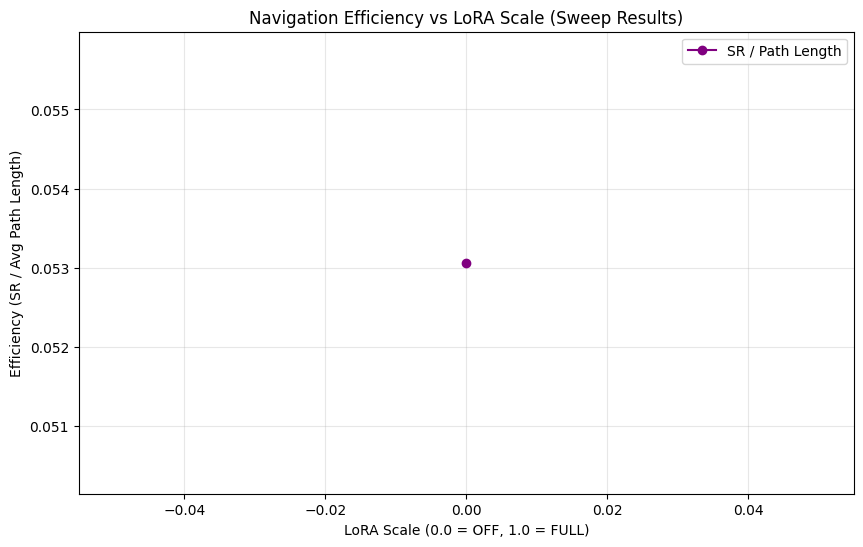

### LoRA Scale Sweep Results Table


,lora_scale,success_rate,collision_rate,avg_path_length,efficiency
25,0.0,1.0,0.0,18.845173,0.053064


In [46]:
if os.path.exists(master_csv):
    df_sweep = pd.read_csv(master_csv)
    df_sweep = df_sweep[df_sweep['exp_id'].str.contains('Scale_Sweep', na=False)]
    df_sweep['lora_scale'] = pd.to_numeric(df_sweep['lora_scale'], errors='coerce')
    df_sweep = df_sweep.dropna(subset=['lora_scale']).sort_values(by='lora_scale')

    if not df_sweep.empty:
        # Calculate Efficiency Metric: Success Rate / Avg Path Length
        df_sweep['efficiency'] = df_sweep['success_rate'] / df_sweep['avg_path_length']
        
        plt.figure(figsize=(10, 6))
        plt.plot(df_sweep['lora_scale'], df_sweep['efficiency'], marker='o', linestyle='-', color='purple', label='SR / Path Length')
        
        plt.xlabel('LoRA Scale (0.0 = OFF, 1.0 = FULL)')
        plt.ylabel('Efficiency (SR / Avg Path Length)')
        plt.title('Navigation Efficiency vs LoRA Scale (Sweep Results)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
        
        print("### LoRA Scale Sweep Results Table")
        display(df_sweep[['lora_scale', 'success_rate', 'collision_rate', 'avg_path_length', 'efficiency']])
    else:
        print("No Scale Sweep data found in CSV.")
else:
    print(f"{master_csv} not found.")

## 3. Comparison: GT vs Discrepancy (Estimated Knowledge)
Comparing performance when using Ground Truth vs Discrepancy-based estimation for Switching and Adaptive behaviors.

In [47]:
comp_behaviors = ['switching_gt', 'switching_discrepancy', 'adaptive_gt', 'adaptive_discrepancy']
df_comp = load_results(scenarios, comp_behaviors)

print("### Comparison Table (GT vs Discrepancy)")
display(df_comp)

print("\n### Comparison Video Grid (GT vs Discrepancy)")
display(generate_video_grid(scenarios, comp_behaviors))

JSONDecodeError: Expecting value: line 71 column 44 (char 2456)